# CD-Dynamax experiments via Config Files
## A walkthrough through loading, overriding, and creating cd-dynamax configs

This notebook walks through cd-dynamax's config system, explains what it provides, and shows *why* it's useful and *how* it actually works.
- Read [`../scripts/README.md`](../scripts/README.md) for the experimentation harness built on top of them.
    - `demos/python/scripts/` runs every experiment purely from config files

Three things a config buys you that hand-writing the model inline doesn't:

- **Reproducibility**: a config file *is* the experiment definition, so re-running the same file combination reproduces the same setup
- **Sweeps without code edits**: swap one file (a different filter, solver, optimizer) and rerun; nothing else changes.
- **A clean split between "experiment" and "code"**: many experiment variants can live as small, diffable text files instead of duplicated notebook cells.

We will walk through how to load, override, and create cd-dynamax configs, step by step, by calling the same loader functions the scripts call.
- see [`../configs/README.md`](../configs/README.md) for the full field reference.

There's **no config-file magic** beyond plain Python functions:
- you can use and call directly, from a script, a notebook, or anywhere else.

### Set-up

In [1]:
# Generic imports and setup
import os
import tempfile

import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
import matplotlib.pyplot as plt


In [2]:
# Setup for CD-Dynamax experiment using configuration files
from cd_dynamax.src.utils.experiment_utils import (
    create_cddynamax_model_from_config,
    create_cddynamax_filter_from_config,
)
from cd_dynamax.src.utils.data_generator import generate_data_from_config
from cd_dynamax.src.utils.simulation_utils import filter_and_forecast

# Same configs/ directory used by the demos/python/scripts
config_path = "../configs/"

# Scratch directory for anything this notebook writes, so re-running it
# never leaves artifacts behind in the tracked demos/ tree
scratch_dir = tempfile.mkdtemp(prefix="cd_dynamax_config_demo_")
print("Scratch directory:", scratch_dir)

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


Scratch directory: /tmp/cd_dynamax_config_demo_6xdazb_l


## 1. Load an existing config set-up: CD-LGSSM with first coordinate observed

Start by loading the same three configs used in the first example in [`scripts/README.md`](../scripts/README.md):

```bash
python3 run_filter_then_forecast.py \\
--data_config_file data/true_cdlgssm_data_x1  \\
--model_config_file model/cdlgssm_x1  \\
--filter_config_file filter/kf
```


Each config type has its own loader function. They configure different aspects of the experiment, all defined in

- [`experiment_utils.py`](../../../cd_dynamax/src/utils/experiment_utils.py)
- [`data_generator.py`](../../../cd_dynamax/src/utils/data_generator.py))

A script or notebook just calls them directly, there is **no separate "config engine" to learn**.

In [3]:
# Data Generation: Load Config and simulate data
data, data_key = generate_data_from_config(
    config_path=config_path,
    data_config_file="data/true_cdlgssm_data_x1",
    data_save_file=os.path.join(scratch_dir, "true_cdlgssm_x1_data.pkl"),
)

# cd-dynamax model config
model, params, props = create_cddynamax_model_from_config(
    config_path=config_path,
    true_model_config_file="model/cdlgssm_x1",
)

# cd-dynamax filter config
filter_hyperparams, filter_info = create_cddynamax_filter_from_config(
    config_path=config_path,
    filter_config_file="filter/kf",
)

# Print summary
print(f"Model: {type(model).__name__} (state_dim={model.state_dim}, emission_dim={model.emission_dim})")
print(f"Data: t_emissions {data['t_emissions'].shape}, emissions {data['emissions'].shape}")
print(f"Filter: {filter_info['name']}")

DATA Warning: 'data_save_file' in config is set to=data/true_cdlgssm_x1_data.pkl 
 we are using the provided data_save_file=/tmp/cd_dynamax_config_demo_6xdazb_l/true_cdlgssm_x1_data.pkl instead.
Sampling from SDE solver path: this may be an unnecessarily poor approximation if you're simulating from a linear SDE. It is an appropriate choice for non-linear SDEs.
CD-LGSSM Sampling from continuous-discrete linear Gaussian SSM path
DATA GENERATED: States and emissions sampled from the true model.
Data saved to /tmp/cd_dynamax_config_demo_6xdazb_l/true_cdlgssm_x1_data.pkl.
Model: ContDiscreteLinearGaussianSSM (state_dim=3, emission_dim=1)
Data: t_emissions (1000, 1), emissions (1000, 1)
Filter: Kalman Filtering


### 1.a: Inspect what got built

Following dynamax conventions, cd-dynamax models use `params` and `props` as plain pytrees.
- `props` mirrors the same structure as `params`, but each leaf is a `ParameterProperties` object rather than an array
    - e.g. marking whether that parameter is trainable.

**The config only determined their values, so from here on it's ordinary cd-dynamax/JAX code.**

In [4]:
print("Dynamics weights:\n", params.dynamics.weights)
print("\nEmission covariance:\n", params.emissions.cov)
print("\nIs dynamics.weights trainable?", props.dynamics.weights.trainable)

Dynamics weights:
 [[-0.1 -0.  -0. ]
 [-0.  -0.1 -0. ]
 [-0.  -0.  -0.1]]

Emission covariance:
 [[0.1]]

Is dynamics.weights trainable? False


### 1.b: Run it: filter + forecast

Besides configs, cd-dynamax provides useful functions for running filters and forecasts.
- For instance, the [`run_filter_then_forecast.py`](../scripts/run_filter_then_forecast.py) script provides filter_and_forecast functionality.

We can follow the same computation, e.g.,
- the first 80% of the horizon is filtered, and the remainder is forecast open-loop from there.

Filtering marginal log-likelihood: -360.37697217527733


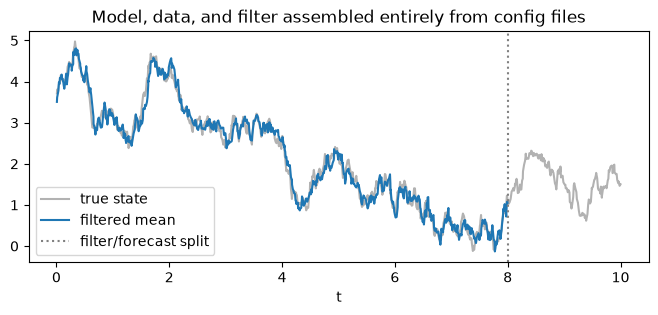

In [5]:
# Set time horizons for filtering and forecasting
T0 = data["t_emissions"][0]
T_end = data["t_emissions"][-1]
T_filter_end = T0 + 0.8 * (T_end - T0)

# Use the filter_and_forecast function to run filtering and forecasting
(
    filtered,
    forecasted,
    start_idx_filter,
    stop_idx_filter,
    start_idx_forecast,
    stop_idx_forecast,
) = filter_and_forecast(
    model_params=params,
    filter_hyperparams=filter_hyperparams,
    t_emissions=data["t_emissions"],
    emissions=data["emissions"],
    T0=T0,
    T_filter_end=T_filter_end,
    T_forecast_end=T_end,
    key=10,
)

# Print the filtering marginal log-likelihood
print("Filtering marginal log-likelihood:", filtered.marginal_loglik)

# Print the filtering results and plot the filtered means against the true states
t = data["t_emissions"][:, 0]  # flatten (num_obs, 1) -> (num_obs,) for plotting
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(t, data["states"][:, 0], color="black", alpha=0.3, label="true state")
ax.plot(t[start_idx_filter:stop_idx_filter], filtered.filtered_means[:, 0], label="filtered mean")
ax.axvline(float(T_filter_end[0]), color="gray", linestyle=":", label="filter/forecast split")
ax.legend()
ax.set_xlabel("t")
ax.set_title("Model, data, and filter assembled entirely from config files")
plt.show()

## 2. Beyond static configs: override one field without touching the file

Every config loader in cd-dynamax takes an `overrides` dict of `{"section.option": value}` pairs
- see `override_config` in [`experiment_utils.py`](../../../cd_dynamax/src/utils/experiment_utils.py)

This overridden operation is applied *before* the file's own values are read.

For instance, this is exactly what the CLI scripts' `--data_key` and `--enforce_twin_experiment` flags do internally
- see [`../configs/README.md`](../configs/README.md) for the full mechanism, including the caveat that config values are `eval()`'d.

What this means is that you can change a single configuration option on the fly without modifying the original config file.

### Same data config, different PRNG seed

In [6]:
# Note: whenever a "data_generation.key" override is used,
# the loader automatically appends a "_datakey<value>" suffix to the save file,
# so this can't silently overwrite the run above.
data_key7, _ = generate_data_from_config(
    config_path=config_path,
    data_config_file="data/true_cdlgssm_data_x1",
    data_save_file=os.path.join(scratch_dir, "true_cdlgssm_x1_data.pkl"),
    overrides={"data_generation.key": 7},
)

print("Same emissions for key 0 and key 7?", bool(jnp.allclose(data["emissions"], data_key7["emissions"])))


DATA Warning: 'data_save_file' in config is set to=data/true_cdlgssm_x1_data.pkl 
 we are using the provided data_save_file=/tmp/cd_dynamax_config_demo_6xdazb_l/true_cdlgssm_x1_data.pkl instead.
Sampling from SDE solver path: this may be an unnecessarily poor approximation if you're simulating from a linear SDE. It is an appropriate choice for non-linear SDEs.
CD-LGSSM Sampling from continuous-discrete linear Gaussian SSM path
DATA GENERATED: States and emissions sampled from the true model.
Data saved to /tmp/cd_dynamax_config_demo_6xdazb_l/true_cdlgssm_x1_data_datakey7.pkl.
Same emissions for key 0 and key 7? False


### Same filter, a coarser final integration step -- no file edited.

In [7]:
# Load same KF configuration, but with a coarser final integration step
filter_hyperparams_coarse, _ = create_cddynamax_filter_from_config(
    config_path=config_path,
    filter_config_file="filter/kf",
    overrides={"KF.dt_final": 1e-2},
)
print("Default dt_final:", filter_hyperparams.dt_final, "| overridden:", filter_hyperparams_coarse.dt_final)

Default dt_final: 0.0001 | overridden: 0.01


## 3. Build and write a new config from scratch

A config is just a text file, so nothing stops you from generating one programmatically
- e.g. to script a parameter sweep, or
- to sanity-check a new model definition in isolation before adding it to `configs/`.

`config_path` is shared across every axis (`data/`, `model/`, `solver/`, ...)
- a self-contained experiment example needs its own `model/` and `solver/` file alongside the `data/` file

In what follows, we write all three into the scratch directory below.
- See [`../configs/README.md`](../configs/README.md) for annotated templates of each axis to copy from instead of starting blank.

In [8]:
# Scratch directory setup
os.makedirs(os.path.join(scratch_dir, "solver"), exist_ok=True)
os.makedirs(os.path.join(scratch_dir, "model"), exist_ok=True)
os.makedirs(os.path.join(scratch_dir, "data"), exist_ok=True)

In [9]:
# Write the solver configuration to the scratch directory
with open(os.path.join(scratch_dir, "solver", "quickstart_solver"), "w") as f:
    f.write(
        '''[diffeqsolve_settings]
        solver: None
        stepsize_controller: dfx.ConstantStepSize()
        adjoint: dfx.RecursiveCheckpointAdjoint()
        dt0: 0.01
        max_steps: 1e4
        '''
    )

In [10]:
# Define a cd-dynamax model
# CD-LGSSM model, defined entirely from scratch
with open(os.path.join(scratch_dir, "model", "quickstart_model"), "w") as f:
    f.write(
        '''[model]
        class_name: CDLGSSM
        state_dim: 2
        emission_dim: 1
        solver_config_file: solver/quickstart_solver

        [initial_values]
        initial_mean = {"params": jnp.zeros(state_dim), "props": ParameterProperties(trainable=False)}
        initial_cov = {"params": jnp.eye(state_dim), "props": ParameterProperties(trainable=False, constrainer=RealToPSDBijector())}
        dynamics_weights = {"params": -0.1 * jnp.eye(state_dim), "props": ParameterProperties(trainable=False)}
        dynamics_diffusion_coefficient = {"params": jnp.eye(state_dim), "props": ParameterProperties(trainable=False)}
        dynamics_diffusion_cov = {"params": jnp.eye(state_dim), "props": ParameterProperties(trainable=False, constrainer=RealToPSDBijector())}
        emission_weights = {"params": jnp.array([[1.0, 0.0]]), "props": ParameterProperties(trainable=False)}
        emission_cov = {"params": 0.1 * jnp.eye(emission_dim), "props": ParameterProperties(trainable=False, constrainer=RealToPSDBijector())}
        '''
    )

In [11]:
# Data configuration, sampling 200 points irregularly between t0=0.0 and t1=5.0
with open(os.path.join(scratch_dir, "data", "quickstart_data"), "w") as f:
    f.write(
        f'''[data_generation]
        key: 0
        t0: 0.0
        t1: 5.0
        num_samples: 200
        irregular_samples: True
        true_model_config_file: model/quickstart_model

        [data_saving]
        data_save_file: {os.path.join(scratch_dir, "quickstart_data.pkl")}
        '''
    )

Now, we can check whether the new config files work correctly by generating data and creating a model from them.

In [12]:
# Generate data: as per the quickstart config
quickstart_data, _ = generate_data_from_config(
    config_path=scratch_dir,
    data_config_file="data/quickstart_data",
)

# CD-LGSSM model: as per the quickstart config
quickstart_model, quickstart_params, quickstart_props = create_cddynamax_model_from_config(
    config_path=scratch_dir,
    true_model_config_file="model/quickstart_model",
)

# Print loaded model and data information
print("Loaded a model + data defined entirely from scratch:")
print(f"{type(quickstart_model).__name__} state_dim={quickstart_model.state_dim} emission_dim={quickstart_model.emission_dim}")
print("emissions shape:", quickstart_data["emissions"].shape)

Sampling from SDE solver path: this may be an unnecessarily poor approximation if you're simulating from a linear SDE. It is an appropriate choice for non-linear SDEs.
CD-LGSSM Sampling from continuous-discrete linear Gaussian SSM path
DATA GENERATED: States and emissions sampled from the true model.
Data saved to /tmp/cd_dynamax_config_demo_6xdazb_l/quickstart_data.pkl.
Loaded a model + data defined entirely from scratch:
ContDiscreteLinearGaussianSSM state_dim=2 emission_dim=1
emissions shape: (200, 1)


## Summary

Key UDFs
- `create_cddynamax_model_from_config`, `create_cddynamax_filter_from_config`, and `generate_data_from_config`
    - These are the actual functions behind every `--*_config_file` flag in `scripts/`
        - Nothing a notebook does here is unavailable to a script, and vice versa!

Working with config files
- `overrides={"section.option": value}` patches one field without touching a file
    - see [`../configs/README.md`](../configs/README.md) for the full mechanism and its caveats (config values are `eval()`'d, so only load configs you trust).

Directly editing config files
- A config is just a text file in the format described in [`../configs/README.md`](../configs/README.md)
    - write one directly, as above, or copy the annotated templates there as a starting point.